# **Advanced Topics in Natural Language Processing**

Group 5
- Margherita Grosso
- Joana Rio Maior
- Nikolay Varamezov
- Michael Webster


In [1]:
#If running on colab
#!git clone https://github.com/michaelwebbie/ATNLP_Group5.git
#%cd /content/ATNLP_Group5

Cloning into 'ATNLP_Group5'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 53 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 24.44 KiB | 8.15 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/ATNLP_Group5


In [2]:
!git clone https://github.com/brendenlake/SCAN.git

Cloning into 'SCAN'...
remote: Enumerating objects: 205, done.
remote: Total 205 (delta 0), reused 0 (delta 0), pack-reused 205 (from 1)
Receiving objects: 100% (205/205), 11.10 MiB | 16.17 MiB/s, done.
Resolving deltas: 100% (173/173), done.


## Imports

In [6]:
import os
import random
import sys
import math
from collections import defaultdict
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW

import matplotlib.pyplot as plt

#Imports from Scripts folder
from Scripts.transformer import Transformer
from Scripts.dataloader import load_pairs, ScanDataLoader
from Scripts.train import train_model
from Scripts.decoder import greedy_decode
from Scripts.metrics import token_accuracy, sequence_accuracy, token_accuracy_exp1
from Scripts.evaluate import evaluate_exp1_token, evaluate_exp2, evaluate_exp3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [7]:
#Full dataset size
all_pairs = load_pairs("SCAN/tasks.txt")
print(len(all_pairs))

20910


Building a dictionary to map a command string

In [8]:
cmd_to_pair = {src: (src, tgt) for src, tgt in all_pairs}

# Experiment 1
- First (1a) - full supervision (SCAN/simple_split)
- Second (1b) - Use SCAN/simple_split/size_variations to train with varying sizes, measuring on ordered token-level accuracy over the full sequence

## Experiment 1a

- Simple train-test split
The network generalizes by recombining pieces of existing commands to interpret new ones.
The simple split includes only primitive commands and simple compositions.

Hyperparameters Exp 1

In [ ]:
BATCH_SIZE_1 = 64
EMB_DIM_1     = 128
N_LAYERS_1    = 1
N_HEADS_1     = 8
FF_DIM_1      = 512
DROPOUT_1     = 0.05
MAX_LEN_1     = 100
LR_1          = 7e-4
GRAD_CLIP_1   = 1.0

N_RUNS_1      = 5

In [ ]:
#ScanDataLoader defined in scripts.dataloader.py
data_1a = ScanDataLoader(
    train_file="SCAN/simple_split/tasks_train_simple.txt",
    test_file="SCAN/simple_split/tasks_test_simple.txt",
    batch_size=BATCH_SIZE_1,
    cmd_to_pair=cmd_to_pair,
    device=device,
)

train_loader_1a, test_loader_1a, src_vocab_1a, tgt_vocab_1a = data_1a.load()
len_train_1a = data_1a.train_size

pad_idx = tgt_vocab_1a.stoi["<PAD>"]
all_accs = []

##### Calculate number of epochs for 100K steps

As the SCAN paper fixes training steps and not epochs, to reproduce results we compute number of epochs needed by considering the new batch size and number of samples in the dataset.

In [ ]:
print(100000/BATCH_SIZE_1/(len_train_1a/BATCH_SIZE_1)) #Epochs for 100K training steps

5.978000956480153


In [ ]:
NUM_EPOCHS_1  = math.ceil(100000/len_train_1a)

##### Modelling, training, and evaluation

In [ ]:
#Loop for muliple runs (N_RUNS_1)
for r in range(N_RUNS_1):
    print(f"\nEXPERIMENT 1A - Run {r+1}/{N_RUNS_1}")

    model = Transformer(
        src_vocab_size=len(src_vocab_1a),
        tgt_vocab_size=len(tgt_vocab_1a),
        src_pad_idx=src_vocab_1a.stoi["<PAD>"],
        tgt_pad_idx=tgt_vocab_1a.stoi["<PAD>"],
        emb_dim=EMB_DIM_1,
        num_layers=N_LAYERS_1,
        num_heads=N_HEADS_1,
        forward_dim=FF_DIM_1,
        dropout=DROPOUT_1,
        max_len=MAX_LEN_1
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=LR_1)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

    train_model(
        model=model,
        train_loader=train_loader_1a,
        optimizer=optimizer,
        criterion=criterion,
        num_epochs=NUM_EPOCHS_1,
        grad_clip=GRAD_CLIP_1,
        device=device,
    )

    tok_acc = evaluate_exp1_token(
        model=model,
        data_loader=test_loader_1a,
        tgt_vocab=tgt_vocab_1a,
        max_len=MAX_LEN_1,
        device=device,
    )

    print(f"Run {r+1} — Token Accuracy: {tok_acc:.4f}")
    all_accs.append(tok_acc)

avg_acc = np.mean(all_accs)
std_acc = np.std(all_accs)

print(f"\n>>> Average token accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")


EXPERIMENT 1A - Run 1/5
Epoch 001 | Loss 0.5699
Epoch 002 | Loss 0.1545
Epoch 003 | Loss 0.0827
Epoch 004 | Loss 0.0546
Epoch 005 | Loss 0.0398
Epoch 006 | Loss 0.0333
Run 1 — Token Accuracy: 0.9985

EXPERIMENT 1A - Run 2/5
Epoch 001 | Loss 0.5955
Epoch 002 | Loss 0.1713
Epoch 003 | Loss 0.0925
Epoch 004 | Loss 0.0611
Epoch 005 | Loss 0.0431
Epoch 006 | Loss 0.0333
Run 2 — Token Accuracy: 0.9990

EXPERIMENT 1A - Run 3/5
Epoch 001 | Loss 0.5853
Epoch 002 | Loss 0.1479
Epoch 003 | Loss 0.0804
Epoch 004 | Loss 0.0514
Epoch 005 | Loss 0.0364
Epoch 006 | Loss 0.0266
Run 3 — Token Accuracy: 0.9981

EXPERIMENT 1A - Run 4/5
Epoch 001 | Loss 0.5830
Epoch 002 | Loss 0.1572
Epoch 003 | Loss 0.0819
Epoch 004 | Loss 0.0533
Epoch 005 | Loss 0.0383
Epoch 006 | Loss 0.0272
Run 4 — Token Accuracy: 0.9987

EXPERIMENT 1A - Run 5/5
Epoch 001 | Loss 0.6264
Epoch 002 | Loss 0.1810
Epoch 003 | Loss 0.0856
Epoch 004 | Loss 0.0501
Epoch 005 | Loss 0.0378
Epoch 006 | Loss 0.0297
Run 5 — Token Accuracy: 0.9959


## Experiment 1B

- Vary the size of the simple training split
- Train the best overall network by varying the number of distinct training examples shown to the model.

In [ ]:
#To run across muliple splits
def run_exp1b(split_name, train_file, test_file, n_runs=N_RUNS_1):
    print(f"\nEXPERIMENT 1B — Split {split_name}")

    data = ScanDataLoader(
        train_file=train_file,
        test_file=test_file,
        cmd_to_pair=cmd_to_pair,
        batch_size=BATCH_SIZE_1,
        device=device,
    )

    train_loader, test_loader, src_vocab, tgt_vocab = data.load()

    train_len = data.train_size
    batch = BATCH_SIZE_1

    # Compute epoch count to reach 100K steps (different for each training set)
    num_epochs = math.ceil(100000 / train_len)
    print(f"Train size: {train_len}")
    print(f"Epochs for 100K steps: {num_epochs}")

    pad_idx = tgt_vocab.stoi["<PAD>"]
    accuracies = []

    for r in range(n_runs):
        print(f"\n--- Run {r+1}/{n_runs} ---")

        model = Transformer(
            src_vocab_size=len(src_vocab),
            tgt_vocab_size=len(tgt_vocab),
            src_pad_idx=pad_idx,
            tgt_pad_idx=pad_idx,
            emb_dim=EMB_DIM_1,
            num_layers=N_LAYERS_1,
            num_heads=N_HEADS_1,
            forward_dim=FF_DIM_1,
            dropout=DROPOUT_1,
            max_len=MAX_LEN_1
        ).to(device)

        optimizer = AdamW(model.parameters(), lr=LR_1)
        criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

        train_model(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            num_epochs=num_epochs,
            grad_clip=GRAD_CLIP_1,
            device=device,
        )

        tok_acc = evaluate_exp1_token(
            model=model,
            data_loader=test_loader,
            tgt_vocab=tgt_vocab,
            max_len=MAX_LEN_1,
            device=device
        )

        print(f"Run {r+1} Token Accuracy: {tok_acc:.4f}")
        accuracies.append(tok_acc)

    avg = np.mean(accuracies)
    std = np.std(accuracies)

    print(f"\nAverage for Split {split_name}: Token accuracy: {avg*100:.2f}% ± {std*100:.2f}%")

    return accuracies, avg, std


In [ ]:
splits = ["p1","p2","p4","p8","p16","p32","p64"]

results = {}

for s in splits:
    results[s] = run_exp1b(
        split_name=s,
        train_file=f"SCAN/simple_split/size_variations/tasks_train_simple_{s}.txt",
        test_file=f"SCAN/simple_split/size_variations/tasks_test_simple_{s}.txt",
        n_runs=N_RUNS_1
    )


EXPERIMENT 1B — Split p1
Train size: 209
Epochs for 100K steps: 479

--- Run 1/5 ---
Epoch 001 | Loss 1.9891
Epoch 002 | Loss 1.6082
Epoch 003 | Loss 1.4479
Epoch 004 | Loss 1.2714
Epoch 005 | Loss 1.1115
Epoch 006 | Loss 1.0074
Epoch 007 | Loss 0.8824
Epoch 008 | Loss 0.8025
Epoch 009 | Loss 0.8061
Epoch 010 | Loss 0.7600
Epoch 011 | Loss 0.7432
Epoch 012 | Loss 0.6837
Epoch 013 | Loss 0.6909
Epoch 014 | Loss 0.6618
Epoch 015 | Loss 0.6276
Epoch 016 | Loss 0.6073
Epoch 017 | Loss 0.5952
Epoch 018 | Loss 0.5612
Epoch 019 | Loss 0.5531
Epoch 020 | Loss 0.5527
Epoch 021 | Loss 0.5265
Epoch 022 | Loss 0.4992
Epoch 023 | Loss 0.5037
Epoch 024 | Loss 0.4628
Epoch 025 | Loss 0.4656
Epoch 026 | Loss 0.4473
Epoch 027 | Loss 0.4174
Epoch 028 | Loss 0.4249
Epoch 029 | Loss 0.3801
Epoch 030 | Loss 0.3722
Epoch 031 | Loss 0.3563
Epoch 032 | Loss 0.3527
Epoch 033 | Loss 0.3264
Epoch 034 | Loss 0.3135
Epoch 035 | Loss 0.3052
Epoch 036 | Loss 0.3241
Epoch 037 | Loss 0.2899
Epoch 038 | Loss 0.2446
Ep

##### Graphically

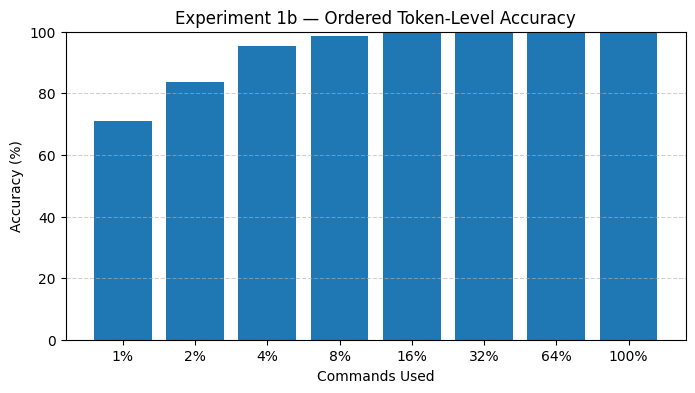

In [ ]:
labels = ["1%", "2%", "4%", "8%", "16%", "32%", "64%", "100%"]
values = [results[f"p{i}"][1] for i in [1, 2, 4, 8, 16, 32, 64]] + [avg_acc]

plt.figure(figsize=(8,4))
plt.bar(labels, [v * 100 for v in values])
plt.ylabel("Accuracy (%)")
plt.xlabel("Commands Used")
plt.title("Experiment 1b — Ordered Token-Level Accuracy")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


# Experiment 2
- Test length generalization using SCAN/length_split files
- Models now tests the transformer's ability to generalize to longer sequences than those seen in training.
- Use of oracle decoding to test effect on token and sequence accuracy

In [6]:
#Decode seperately with and without oracle
def decode_exp2(
    model,
    loader,
    sos_idx,
    eos_idx,
    pad_idx,
    device,
    use_oracle=False,
    oracle_lengths=None,
    max_len=60,
):
    preds = []
    golds = []
    ex_idx = 0

    model.eval()
    with torch.no_grad():
        for src, _, tgt_out in loader:
            src = src.to(device)
            tgt_out = tgt_out.to(device)

            for i in range(src.size(0)):
                src_i = src[i].unsqueeze(0)
                gold = tgt_out[i].tolist()

                if use_oracle:
                    pred = greedy_decode(
                        model,
                        src_i,
                        sos_idx,
                        eos_idx,
                        oracle_length=oracle_lengths[ex_idx],
                        forbid_eos=True,
                        device=device,
                    )[0]
                else:
                    pred = greedy_decode(
                        model,
                        src_i,
                        sos_idx,
                        eos_idx,
                        max_len=max_len,
                        device=device,
                    )[0]

                preds.append(pred)
                golds.append(gold)
                ex_idx += 1

    return preds, golds


Collect token and sequence-level accuracy grouped by:
 - action sequence length
 - command length

In [7]:
def compute_exp2_metrics(preds, golds, pad_idx, eos_idx):
    seq_correct = 0
    tok_correct = 0
    tok_total = 0

    for p, g in zip(preds, golds):
        c, t = token_accuracy(p, g, pad_idx, eos_idx)
        tok_correct += c
        tok_total += t

        if sequence_accuracy(p, g, pad_idx, eos_idx):
            seq_correct += 1

    seq_acc = 100 * seq_correct / len(golds)
    tok_acc = 100 * tok_correct / tok_total
    return seq_acc, tok_acc

In [8]:
def group_exp2_metrics(
    preds,
    golds,
    cmd_lengths,
    act_lengths,
    pad_idx,
    eos_idx,
):
    tok_by_act = defaultdict(lambda: [0, 0])
    tok_by_cmd = defaultdict(lambda: [0, 0])
    seq_by_act = defaultdict(lambda: [0, 0])
    seq_by_cmd = defaultdict(lambda: [0, 0])

    for i, (p, g) in enumerate(zip(preds, golds)):
        c, t = token_accuracy(p, g, pad_idx, eos_idx)
        act_len = act_lengths[i]
        cmd_len = cmd_lengths[i]

        tok_by_act[act_len][0] += c
        tok_by_act[act_len][1] += t
        tok_by_cmd[cmd_len][0] += c
        tok_by_cmd[cmd_len][1] += t

        seq_ok = sequence_accuracy(p, g, pad_idx, eos_idx)
        seq_by_act[act_len][0] += seq_ok
        seq_by_act[act_len][1] += 1
        seq_by_cmd[cmd_len][0] += seq_ok
        seq_by_cmd[cmd_len][1] += 1

    return tok_by_act, tok_by_cmd, seq_by_act, seq_by_cmd


In [9]:
def run_exp2(
    train_loader,
    test_loader,
    src_vocab,
    tgt_vocab,
    cmd_lengths,
    act_lengths,
    sos_idx,
    eos_idx,
    pad_idx,
    num_epochs,
    device,
    n_runs=5,
):
    seq_no_all, tok_no_all = [], []
    seq_or_all, tok_or_all = [], []

    agg_tok_act_no = defaultdict(lambda: [0, 0])
    agg_tok_cmd_no = defaultdict(lambda: [0, 0])
    agg_seq_act_no = defaultdict(lambda: [0, 0])
    agg_seq_cmd_no = defaultdict(lambda: [0, 0])

    agg_tok_act_or = defaultdict(lambda: [0, 0])
    agg_tok_cmd_or = defaultdict(lambda: [0, 0])
    agg_seq_act_or = defaultdict(lambda: [0, 0])
    agg_seq_cmd_or = defaultdict(lambda: [0, 0])

    for r in range(n_runs):
        print(f"\nEXPERIMENT 2 — RUN {r+1}/{n_runs}")

        model = Transformer(
            src_vocab_size=len(src_vocab),
            tgt_vocab_size=len(tgt_vocab),
            src_pad_idx=pad_idx,
            tgt_pad_idx=pad_idx,
            emb_dim=EMB_DIM_2,
            num_layers=N_LAYERS_2,
            num_heads=N_HEADS_2,
            forward_dim=FORWARD_DIM_2,
            dropout=DROPOUT_2,
            max_len=MAX_LEN_2,
        ).to(device)

        optimizer = AdamW(model.parameters(), lr=LR_2)
        criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

        train_model(
            model,
            train_loader,
            optimizer,
            criterion,
            num_epochs,
            GRAD_CLIP_2,
            device,
        )

        preds_no, golds = decode_exp2(
            model, test_loader, sos_idx, eos_idx, pad_idx, device
        )
        preds_or, _ = decode_exp2(
            model, test_loader, sos_idx, eos_idx, pad_idx, device,
            use_oracle=True,
            oracle_lengths=act_lengths
        )


        seq_no, tok_no = compute_exp2_metrics(preds_no, golds, pad_idx, eos_idx)
        seq_or, tok_or = compute_exp2_metrics(preds_or, golds, pad_idx, eos_idx)

        seq_no_all.append(seq_no)
        tok_no_all.append(tok_no)
        seq_or_all.append(seq_or)
        tok_or_all.append(tok_or)

        print("\nResults (this run)")
        print(f"No oracle:   Seq={seq_no:.2f}% Tok={tok_no:.2f}%")
        print(f"With oracle: Seq={seq_or:.2f}% Tok={tok_or:.2f}%")

        for d_src, d_dst in [
            (group_exp2_metrics(preds_no, golds, cmd_lengths, act_lengths, pad_idx, eos_idx),
             (agg_tok_act_no, agg_tok_cmd_no, agg_seq_act_no, agg_seq_cmd_no)),
            (group_exp2_metrics(preds_or, golds, cmd_lengths, act_lengths, pad_idx, eos_idx),
             (agg_tok_act_or, agg_tok_cmd_or, agg_seq_act_or, agg_seq_cmd_or)),
        ]:
            for src, dst in zip(d_src, d_dst):
                for k, v in src.items():
                    dst[k][0] += v[0]
                    dst[k][1] += v[1]

    print("\nResults")
    print(f"No oracle:   Seq={np.mean(seq_no_all):.2f}% ± {np.std(seq_no_all):.2f} Tok={np.mean(tok_no_all):.2f}% ± {np.std(tok_no_all):.2f}")
    print(f"With oracle: Seq={np.mean(seq_or_all):.2f}% ± {np.std(seq_or_all):.2f} Tok={np.mean(tok_or_all):.2f}% ± {np.std(tok_or_all):.2f}")

    return (
        agg_tok_act_no, agg_tok_cmd_no, agg_seq_act_no, agg_seq_cmd_no,
        agg_tok_act_or, agg_tok_cmd_or, agg_seq_act_or, agg_seq_cmd_or,
    )


Hyperparameters Exp 2

In [10]:
EMB_DIM_2       = 128
N_LAYERS_2      = 2
N_HEADS_2       = 8
FORWARD_DIM_2   = 256
DROPOUT_2       = 0.15
LR_2            = 2e-4
GRAD_CLIP_2     = 1.0
MAX_LEN_2       = 60
BATCH_SIZE_2    = 16

N_RUNS_2        = 5

##### Load the length split
- Train length max: 22 tokens
- Test length max: 48 tokens

In [11]:
data_exp2 = ScanDataLoader(
    train_file="SCAN/length_split/tasks_train_length.txt",
    test_file="SCAN/length_split/tasks_test_length.txt",
    cmd_to_pair=cmd_to_pair,
    batch_size=BATCH_SIZE_2,
    device=device,
)

train_loader_2, test_loader_2, src_vocab_2, tgt_vocab_2 = data_exp2.load()

In [12]:
src_pad_2 = src_vocab_2.stoi["<PAD>"]
tgt_pad_2 = tgt_vocab_2.stoi["<PAD>"]
SOS_2 = tgt_vocab_2.stoi["<SOS>"]
EOS_2 = tgt_vocab_2.stoi["<EOS>"]

##### Calculate number of Epochs

In [13]:
NUM_EPOCHS_EXP2 = math.ceil(100000 / data_exp2.train_size)

Training

In [14]:
cmd_lengths_2 = [len(src.split()) for (src, tgt) in data_exp2.test_pairs]
act_lengths_2 = [len(tgt.split()) for (src, tgt) in data_exp2.test_pairs]

##### Train

Trains a new model for every run. Evaluates no-oracle accuracy (strict decoding) and oracle accuracy (uses gold output length and forbids EOS).

In [15]:
(
    agg_tok_act_no, agg_tok_cmd_no, agg_seq_act_no, agg_seq_cmd_no,
    agg_tok_act_or, agg_tok_cmd_or, agg_seq_act_or, agg_seq_cmd_or
) = run_exp2(
    train_loader=train_loader_2,
    test_loader=test_loader_2,
    src_vocab=src_vocab_2,
    tgt_vocab=tgt_vocab_2,
    cmd_lengths=cmd_lengths_2,
    act_lengths=act_lengths_2,
    sos_idx=SOS_2,
    eos_idx=EOS_2,
    pad_idx=tgt_pad_2,
    num_epochs=NUM_EPOCHS_EXP2,
    device=device,
    n_runs=N_RUNS_2
)


EXPERIMENT 2 — RUN 1/5
Epoch 001 | Loss 0.8417
Epoch 002 | Loss 0.5251
Epoch 003 | Loss 0.3571
Epoch 004 | Loss 0.1850
Epoch 005 | Loss 0.1237
Epoch 006 | Loss 0.0959

Results (this run)
No oracle:   Seq=0.00% Tok=59.10%
With oracle: Seq=54.16% Tok=83.17%

EXPERIMENT 2 — RUN 2/5
Epoch 001 | Loss 0.8231
Epoch 002 | Loss 0.4964
Epoch 003 | Loss 0.3217
Epoch 004 | Loss 0.1518
Epoch 005 | Loss 0.0965
Epoch 006 | Loss 0.0691

Results (this run)
No oracle:   Seq=0.00% Tok=77.33%
With oracle: Seq=55.92% Tok=89.94%

EXPERIMENT 2 — RUN 3/5
Epoch 001 | Loss 0.8396
Epoch 002 | Loss 0.5227
Epoch 003 | Loss 0.4132
Epoch 004 | Loss 0.2282
Epoch 005 | Loss 0.1290
Epoch 006 | Loss 0.0884

Results (this run)
No oracle:   Seq=0.00% Tok=65.52%
With oracle: Seq=45.56% Tok=86.06%

EXPERIMENT 2 — RUN 4/5
Epoch 001 | Loss 0.8364
Epoch 002 | Loss 0.4930
Epoch 003 | Loss 0.2579
Epoch 004 | Loss 0.1427
Epoch 005 | Loss 0.0951
Epoch 006 | Loss 0.0708

Results (this run)
No oracle:   Seq=0.00% Tok=67.84%
With or

Without oracle token-level accuracy

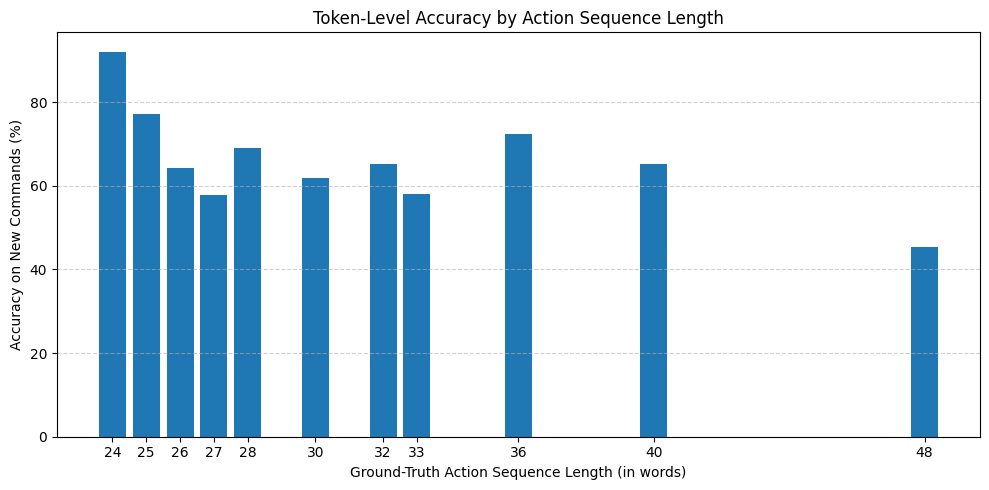

In [54]:
action_lengths = sorted(agg_tok_act_no.keys())
acc_tok_no = [
    100 * agg_tok_act_no[L][0] / agg_tok_act_no[L][1]
    for L in action_lengths
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(action_lengths, acc_tok_no, width=0.8)
ax.set_title("Token-Level Accuracy by Action Sequence Length")
ax.set_xlabel("Ground-Truth Action Sequence Length (in words)")
ax.set_ylabel("Accuracy on New Commands (%)")
y_max = max(acc_tok_no)
upper = min(100, y_max * 1.05)
plt.ylim(0, upper)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_xticks(action_lengths)

plt.tight_layout()
plt.show()


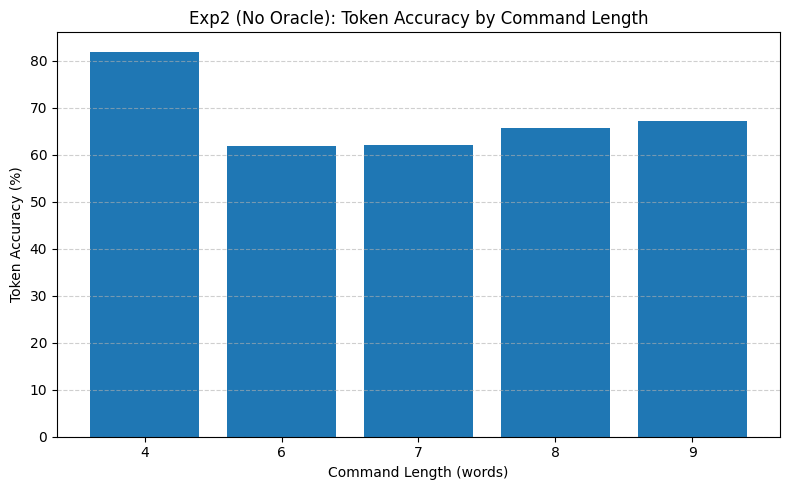

In [55]:
command_lengths = sorted(L for L in agg_tok_cmd_no.keys() if L != 5)
acc_tok_cmd_no = [
    100 * agg_tok_cmd_no[L][0] / agg_tok_cmd_no[L][1]
    for L in command_lengths
]

x = range(len(command_lengths))

plt.figure(figsize=(8, 5))
plt.bar(x, acc_tok_cmd_no)
plt.xticks(x, command_lengths)

plt.title("Exp2 (No Oracle): Token Accuracy by Command Length")
plt.xlabel("Command Length (words)")
plt.ylabel("Token Accuracy (%)")
y_max = max(acc_tok_cmd_no)
upper = min(100, y_max * 1.05)
plt.ylim(0, upper)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

With oracle token-level accuracy

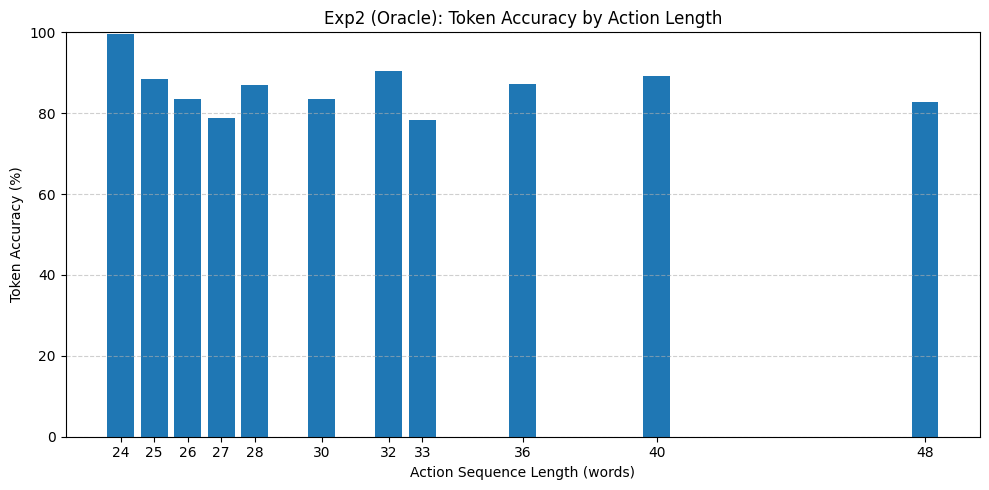

In [56]:
action_lengths = sorted(agg_tok_act_or.keys())
acc_tok_or = [100 * agg_tok_act_or[L][0] / agg_tok_act_or[L][1] for L in action_lengths]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(action_lengths, acc_tok_or, width=0.8)
plt.title("Exp2 (Oracle): Token Accuracy by Action Length")
plt.xlabel("Action Sequence Length (words)")
plt.ylabel("Token Accuracy (%)")
y_max = max(acc_tok_or)
upper = min(100, y_max * 1.05)
plt.ylim(0, upper)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_xticks(action_lengths)
plt.tight_layout()
plt.show()




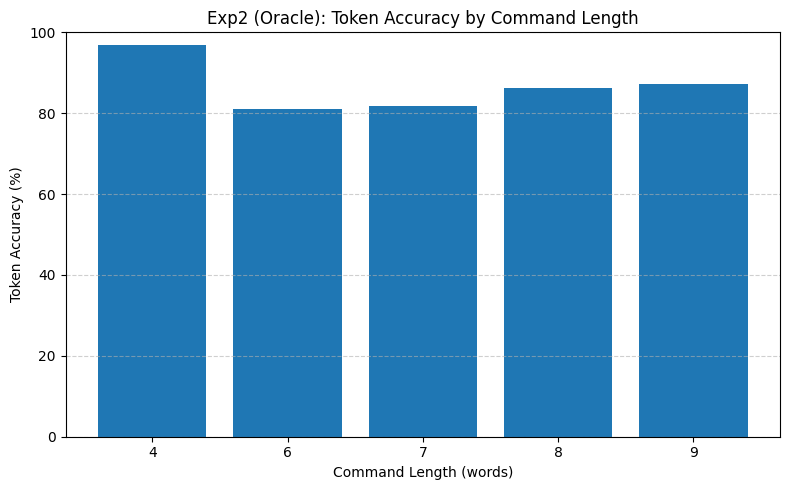

In [57]:
command_lengths = sorted([L for L in agg_tok_cmd_or.keys() if L != 5])
acc_tok_or_cmd = [100 * agg_tok_cmd_or[L][0] / agg_tok_cmd_or[L][1] for L in command_lengths]

x = range(len(command_lengths))

plt.figure(figsize=(8, 5))
plt.bar(x, acc_tok_or_cmd)
plt.xticks(x, command_lengths)

plt.title("Exp2 (Oracle): Token Accuracy by Command Length")
plt.xlabel("Command Length (words)")
plt.ylabel("Token Accuracy (%)")
y_max = max(acc_tok_or_cmd)
upper = min(100, y_max * 1.05)
plt.ylim(0, upper)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


With oracle sequence-level accuracy

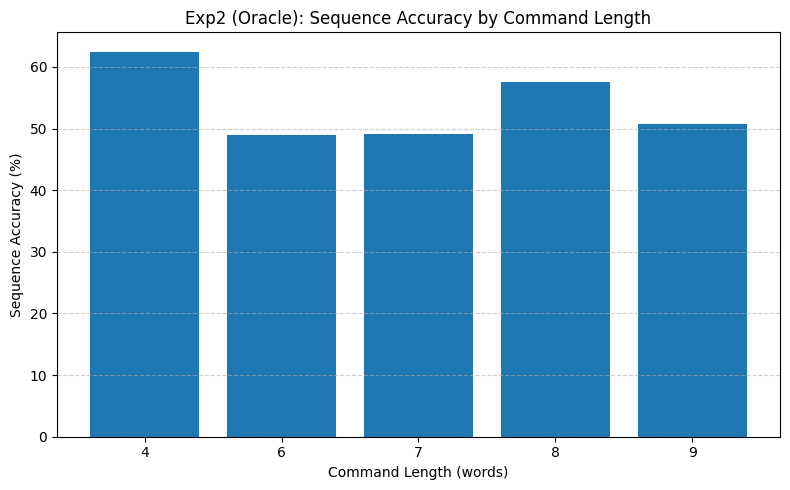

In [58]:
command_lengths = sorted([L for L in agg_seq_cmd_or.keys() if L != 5])

acc_seq_cmd_or = [
    100 * agg_seq_cmd_or[L][0] / agg_seq_cmd_or[L][1]
    for L in command_lengths
]

x = range(len(command_lengths))

plt.figure(figsize=(8, 5))
plt.bar(x, acc_seq_cmd_or)
plt.xticks(x, command_lengths)

plt.title("Exp2 (Oracle): Sequence Accuracy by Command Length")
plt.xlabel("Command Length (words)")
plt.ylabel("Sequence Accuracy (%)")

y_max = max(acc_seq_cmd_or)
upper = min(100, y_max * 1.05)
plt.ylim(0, upper)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


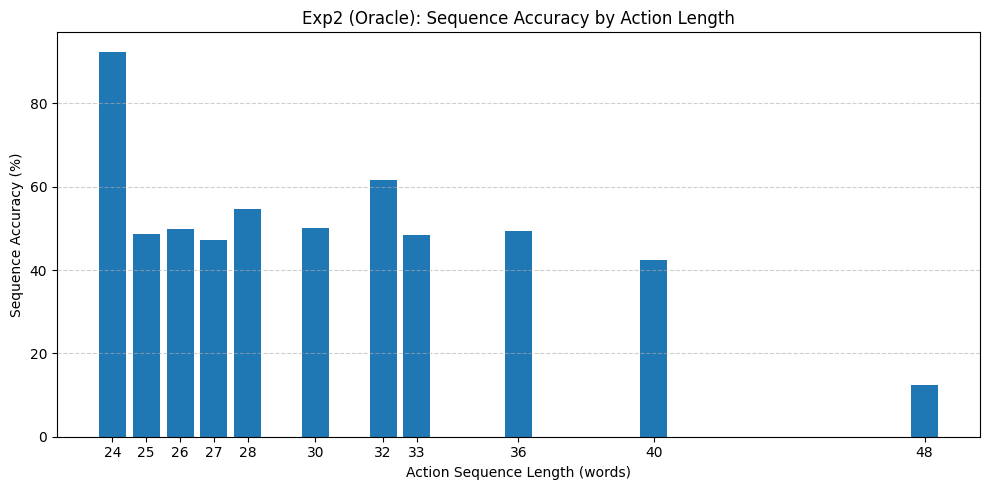

In [67]:
action_lengths = sorted(
    L for L in agg_seq_act_or
    if agg_seq_act_or[L][1] > 0
)

acc_seq_act_or = [
    100 * agg_seq_act_or[L][0] / agg_seq_act_or[L][1]
    for L in action_lengths
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(action_lengths, acc_seq_act_or, width=0.8)

ax.set_title("Exp2 (Oracle): Sequence Accuracy by Action Length")
ax.set_xlabel("Action Sequence Length (words)")
ax.set_ylabel("Sequence Accuracy (%)")

y_max = max(acc_seq_act_or)
ax.set_ylim(0, min(100, y_max * 1.05))

ax.set_xticks(action_lengths)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# Experiment 3
- First, use SCAN/add_prim_split files to test token and seq accuracy when missing TURN_LEFT and JUMP commands in training
- Second, use SCAN/add_prim_split/with_additional_examples for JUMP to see the effect of composed commands
- Training the model on all primitive and composed commands for all of the training data, except that for [JUMP, LTURN] primitive command, the model is only exposed to the primitive action
- How well does the model generalise to composed commands for these primitive actions?

In [20]:
def run_exp3(
    train_loader,
    test_loader,
    src_vocab,
    tgt_vocab,
    num_epochs,
    device,
    n_runs,
):
    seq_scores = []
    tok_scores = []

    src_pad_idx = src_vocab.stoi["<PAD>"]
    tgt_pad_idx = tgt_vocab.stoi["<PAD>"]

    for r in range(n_runs):
        if n_runs > 1:
          print(f"\nEXPERIMENT 3 — RUN {r+1}/{n_runs}")

        model = Transformer(
            src_vocab_size=len(src_vocab),
            tgt_vocab_size=len(tgt_vocab),
            src_pad_idx=src_pad_idx,
            tgt_pad_idx=tgt_pad_idx,
            emb_dim=EMB_DIM_3,
            num_layers=N_LAYERS_3,
            num_heads=N_HEADS_3,
            forward_dim=FORWARD_DIM_3,
            dropout=DROPOUT_3,
            max_len=MAX_LEN_3,
        ).to(device)

        optimizer = AdamW(model.parameters(), lr=LR_3)
        criterion = nn.CrossEntropyLoss(ignore_index=tgt_pad_idx)

        train_model(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            num_epochs=num_epochs,
            grad_clip=GRAD_CLIP_3,
            device=device,
        )

        seq, tok = evaluate_exp3(
            model=model,
            data_loader=test_loader,
            tgt_vocab=tgt_vocab,
            max_len=MAX_LEN_3,
            device=device,
        )

        seq_scores.append(seq)
        tok_scores.append(tok)

        print(f"Run {r+1}: Sequence Acc = {seq:.2f}% | Token Acc = {tok:.2f}%")

    seq_mean = np.mean(seq_scores)
    seq_std  = np.std(seq_scores)
    tok_mean = np.mean(tok_scores)
    tok_std  = np.std(tok_scores)

    if n_runs > 1:
      print(
        f">>> AVERAGES for N={n_runs}: "
        f"Seq={seq_mean:.2f}% ± {seq_std:.2f}% | "
        f"Tok={tok_mean:.2f}% ± {tok_std:.2f}%"
    )
    return seq_scores, tok_scores

Hyperparameters (experiment 3)

In [21]:
EMB_DIM_3     = 128
N_LAYERS_3    = 2
N_HEADS_3     = 8
FORWARD_DIM_3 = 256
DROPOUT_3     = 0.15
LR_3          = 2e-4
GRAD_CLIP_3   = 1.0
MAX_LEN_3     = 50
BATCH_SIZE_3  = 16

N_RUNS_3 = 5

##### Load TURN_LEFT pairs

In [22]:
data_turn = ScanDataLoader(
    train_file="SCAN/add_prim_split/tasks_train_addprim_turn_left.txt",
    test_file="SCAN/add_prim_split/tasks_test_addprim_turn_left.txt",
    cmd_to_pair=cmd_to_pair,
    batch_size=BATCH_SIZE_3,
    device=device,
)

train_loader_turn, test_loader_turn, src_vocab_turn, tgt_vocab_turn = data_turn.load()

##### Calculate number of Epochs

In [23]:
NUM_EPOCHS_TURN = math.ceil(100000/data_turn.train_size)

##### Train TURN_LEFT

In [24]:
print("===== TURN LEFT =====")
seq_turn, tok_turn = run_exp3(
    train_loader_turn,
    test_loader_turn,
    src_vocab_turn,
    tgt_vocab_turn,
    NUM_EPOCHS_TURN,
    device=device,
    n_runs=N_RUNS_3
)

===== TURN LEFT =====

EXPERIMENT 3 — RUN 1/5
Epoch 001 | Loss 0.6633
Epoch 002 | Loss 0.3716
Epoch 003 | Loss 0.1919
Epoch 004 | Loss 0.1051
Epoch 005 | Loss 0.0703
Run 1: Sequence Acc = 21.85% | Token Acc = 76.68%

EXPERIMENT 3 — RUN 2/5
Epoch 001 | Loss 0.6745
Epoch 002 | Loss 0.3508
Epoch 003 | Loss 0.1783
Epoch 004 | Loss 0.1081
Epoch 005 | Loss 0.0768
Run 2: Sequence Acc = 24.92% | Token Acc = 78.72%

EXPERIMENT 3 — RUN 3/5
Epoch 001 | Loss 0.6797
Epoch 002 | Loss 0.3918
Epoch 003 | Loss 0.2755
Epoch 004 | Loss 0.1337
Epoch 005 | Loss 0.0871
Run 3: Sequence Acc = 26.74% | Token Acc = 78.24%

EXPERIMENT 3 — RUN 4/5
Epoch 001 | Loss 0.6621
Epoch 002 | Loss 0.3575
Epoch 003 | Loss 0.1802
Epoch 004 | Loss 0.1002
Epoch 005 | Loss 0.0669
Run 4: Sequence Acc = 19.45% | Token Acc = 80.13%

EXPERIMENT 3 — RUN 5/5
Epoch 001 | Loss 0.6736
Epoch 002 | Loss 0.3880
Epoch 003 | Loss 0.2036
Epoch 004 | Loss 0.1130
Epoch 005 | Loss 0.0807
Run 5: Sequence Acc = 2.48% | Token Acc = 76.74%
>>> AVERA

##### Load JUMP pairs

In [25]:
data_jump = ScanDataLoader(
    train_file="SCAN/add_prim_split/tasks_train_addprim_jump.txt",
    test_file="SCAN/add_prim_split/tasks_test_addprim_jump.txt",
    cmd_to_pair=cmd_to_pair,
    batch_size=BATCH_SIZE_3,
    device=device,
)
train_loader_jump, test_loader_jump, src_vocab_jump, tgt_vocab_jump = data_jump.load()

##### Calculate number of Epochs

In [26]:
NUM_EPOCHS_JUMP = math.ceil(100000/data_jump.train_size)

##### Train JUMP

In [27]:
print("===== JUMP =====")
seq_jump, tok_jump = run_exp3(
    train_loader_jump,
    test_loader_jump,
    src_vocab_jump,
    tgt_vocab_jump,
    NUM_EPOCHS_JUMP,
    device=device,
    n_runs=N_RUNS_3
)

===== JUMP =====

EXPERIMENT 3 — RUN 1/5
Epoch 001 | Loss 0.7272
Epoch 002 | Loss 0.4396
Epoch 003 | Loss 0.3609
Epoch 004 | Loss 0.2490
Epoch 005 | Loss 0.1551
Epoch 006 | Loss 0.1098
Epoch 007 | Loss 0.0843
Run 1: Sequence Acc = 0.52% | Token Acc = 65.89%

EXPERIMENT 3 — RUN 2/5
Epoch 001 | Loss 0.7338
Epoch 002 | Loss 0.4503
Epoch 003 | Loss 0.3539
Epoch 004 | Loss 0.2117
Epoch 005 | Loss 0.1400
Epoch 006 | Loss 0.1063
Epoch 007 | Loss 0.0854
Run 2: Sequence Acc = 0.39% | Token Acc = 69.55%

EXPERIMENT 3 — RUN 3/5
Epoch 001 | Loss 0.7337
Epoch 002 | Loss 0.4432
Epoch 003 | Loss 0.3219
Epoch 004 | Loss 0.1810
Epoch 005 | Loss 0.1225
Epoch 006 | Loss 0.0935
Epoch 007 | Loss 0.0744
Run 3: Sequence Acc = 0.73% | Token Acc = 57.26%

EXPERIMENT 3 — RUN 4/5
Epoch 001 | Loss 0.7315
Epoch 002 | Loss 0.4558
Epoch 003 | Loss 0.3314
Epoch 004 | Loss 0.1996
Epoch 005 | Loss 0.1333
Epoch 006 | Loss 0.1018
Epoch 007 | Loss 0.0813
Run 4: Sequence Acc = 0.19% | Token Acc = 70.94%

EXPERIMENT 3 — RUN

## [JUMP] composed commands

In [28]:
avg_seq_0 = sum(seq_jump) / len(seq_jump)
avg_tok_0 = sum(tok_jump) / len(tok_jump)

In [29]:
sizes = [1, 2, 4, 8, 16, 32]

complex_results_seq = [avg_seq_0]
complex_results_tok = [avg_tok_0]
complex_results_seq_std = [0.0]
complex_results_tok_std = [0.0]

for n in sizes:
    print(f"\nComplex JUMP N={n}")

    seq_scores = []
    tok_scores = []

    for rep in range(1, 6):
        train_file = f"SCAN/add_prim_split/with_additional_examples/tasks_train_addprim_complex_jump_num{n}_rep{rep}.txt"
        test_file  = f"SCAN/add_prim_split/with_additional_examples/tasks_test_addprim_complex_jump_num{n}_rep{rep}.txt"

        print(f"  → REP {rep}: {train_file}")

        data_rep = ScanDataLoader(
            train_file=train_file,
            test_file=test_file,
            cmd_to_pair=cmd_to_pair,
            batch_size=BATCH_SIZE_3,
            device=device,
        )

        train_loader, test_loader, src_vocab, tgt_vocab = data_rep.load()
        num_epochs = math.ceil(100000 / data_rep.train_size)

        seq_list, tok_list = run_exp3(
            train_loader,
            test_loader,
            src_vocab,
            tgt_vocab,
            num_epochs,
            device=device,
            n_runs=1
        )

        seq_scores.append(seq_list[0])
        tok_scores.append(tok_list[0])

    seq_mean = np.mean(seq_scores)
    seq_std  = np.std(seq_scores)

    tok_mean = np.mean(tok_scores)
    tok_std  = np.std(tok_scores)


    complex_results_seq.append(seq_mean)
    complex_results_seq_std.append(seq_std)

    complex_results_tok.append(tok_mean)
    complex_results_tok_std.append(tok_std)
    print(f"Average for N={n}: Seq={seq_mean:.2f}% ± {seq_std:.2f} | Tok={tok_mean:.2f}% ± {tok_std:.2f}")



Complex JUMP N=1
  → REP 1: SCAN/add_prim_split/with_additional_examples/tasks_train_addprim_complex_jump_num1_rep1.txt
Epoch 001 | Loss 0.7068
Epoch 002 | Loss 0.4229
Epoch 003 | Loss 0.3198
Epoch 004 | Loss 0.1836
Epoch 005 | Loss 0.1184
Epoch 006 | Loss 0.0915
Epoch 007 | Loss 0.0734
Run 1: Sequence Acc = 5.07% | Token Acc = 66.50%
  → REP 2: SCAN/add_prim_split/with_additional_examples/tasks_train_addprim_complex_jump_num1_rep2.txt
Epoch 001 | Loss 0.7288
Epoch 002 | Loss 0.4262
Epoch 003 | Loss 0.3509
Epoch 004 | Loss 0.2391
Epoch 005 | Loss 0.1346
Epoch 006 | Loss 0.0965
Epoch 007 | Loss 0.0771
Run 1: Sequence Acc = 3.19% | Token Acc = 69.13%
  → REP 3: SCAN/add_prim_split/with_additional_examples/tasks_train_addprim_complex_jump_num1_rep3.txt
Epoch 001 | Loss 0.7348
Epoch 002 | Loss 0.4448
Epoch 003 | Loss 0.3625
Epoch 004 | Loss 0.2354
Epoch 005 | Loss 0.1483
Epoch 006 | Loss 0.1049
Epoch 007 | Loss 0.0805
Run 1: Sequence Acc = 3.63% | Token Acc = 65.87%
  → REP 4: SCAN/add_pr

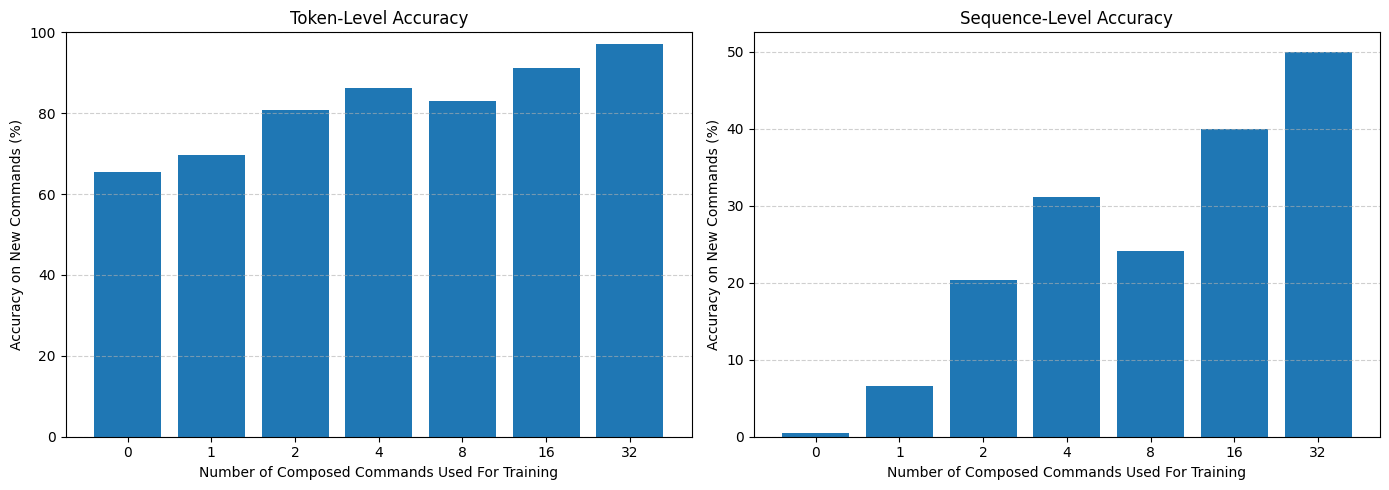

In [30]:
sizes = [0, 1, 2, 4, 8, 16, 32]
x = range(len(sizes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Token-level accuracy
axes[0].bar(x, complex_results_tok)
axes[0].set_title("Token-Level Accuracy")
axes[0].set_xlabel("Number of Composed Commands Used For Training")
axes[0].set_ylabel("Accuracy on New Commands (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sizes)
axes[0].set_ylim(0, min(100, max(complex_results_tok) * 1.05))
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

#Sequence-level accuracy
axes[1].bar(x, complex_results_seq)
axes[1].set_title("Sequence-Level Accuracy")
axes[1].set_xlabel("Number of Composed Commands Used For Training")
axes[1].set_ylabel("Accuracy on New Commands (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sizes)
axes[1].set_ylim(0, min(100, max(complex_results_seq) * 1.05))
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
